In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from operator import index
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from fastai.tabular.all import df_shrink
from google.colab import data_table
from google.colab import files
from google.colab import drive
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

testing = '/content/drive/MyDrive/Testing/KDDTest+.csv'
training = '/content/drive/MyDrive/Testing/KDDTrain+.csv'

train = pd.read_csv(training, encoding='utf-8')
test = pd.read_csv(testing, encoding='utf-8')

train = df_shrink(train, skip=[], obj2cat=True, int2uint=True)
test = df_shrink(test, skip=[], obj2cat=True, int2uint=True)

feature_type_map = {f: (train.dtypes.loc[f], test.dtypes.loc[f]) for f in train.columns}

len(train['class'].cat.categories), len(test['class'].cat.categories)

len(train.service.cat.categories), len(test.service.cat.categories)

def train_test_category_union(feature):
  tcl = len(train[feature].cat.categories)
  tcll = len(test[feature].cat.categories)
  feature_cat_union = train[feature].cat.categories.union(test[feature].cat.categories)
  train[feature] = train[feature].cat.set_categories(feature_cat_union)
  test[feature] = test[feature].cat.set_categories(feature_cat_union)

cat = list(train.select_dtypes(include='category').columns.values)

for f in cat:
  train_test_category_union(f)

class_data_train = train['class']
#one hot encoding on all nominal categories except class
test = pd.get_dummies(test, columns=['protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_host_login', 'is_guest_login'])
train = pd.get_dummies(train, columns=['protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_host_login', 'is_guest_login'])

#label encoding for class column since it is the target variable
le = LabelEncoder()
train['classification'] = le.fit_transform(train['class'])
test['classification'] = le.fit_transform(test['class'])
train.drop('class', axis=1, inplace=True)
test.drop('class', axis=1, inplace=True)

#robust scaling for normalization step
robust_scaler1 = RobustScaler()
robust_scaler2 = RobustScaler()
#data1 = test.values[:, :-1]
data1 = test.values[:, :]
#data2 = train.values[:, :-1]
data2 = train.values[:, :]
data1 = robust_scaler1.fit_transform(data1)
data2 = robust_scaler2.fit_transform(data2)
#converting array back to dataframe
test = pd.DataFrame(data1)
train = pd.DataFrame(data2)

# Preprocessing ends here

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, accuracy_score

# Separates features and labels
X_train = train.drop(train.columns[-1], axis=1)  # all but last col
y_train = train[train.columns[-1]]               # last col is classification
X_test = test.drop(test.columns[-1], axis=1)
y_test = test[test.columns[-1]]

# Initialize the LOF
lof = LocalOutlierFactor(n_neighbors=3, novelty=True, contamination=0.00522) # 3 / 0.00522 : 0.7688520227111426

# Fit on training data
lof.fit(X_train)

# Predict on test data
y_pred = lof.predict(X_test)

# LOF outputs: -1 = anomaly, 1 = normal
# We need: 0 = anomaly, 1 = normal
# Convert predictions
y_pred = np.where(y_pred == -1, 0, 1)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Anomaly (0)", "Normal (1)"]))

Accuracy: 0.7688076650106459

Classification Report:
               precision    recall  f1-score   support

 Anomaly (0)       0.88      0.69      0.77     12833
  Normal (1)       0.68      0.87      0.76      9711

    accuracy                           0.77     22544
   macro avg       0.78      0.78      0.77     22544
weighted avg       0.79      0.77      0.77     22544



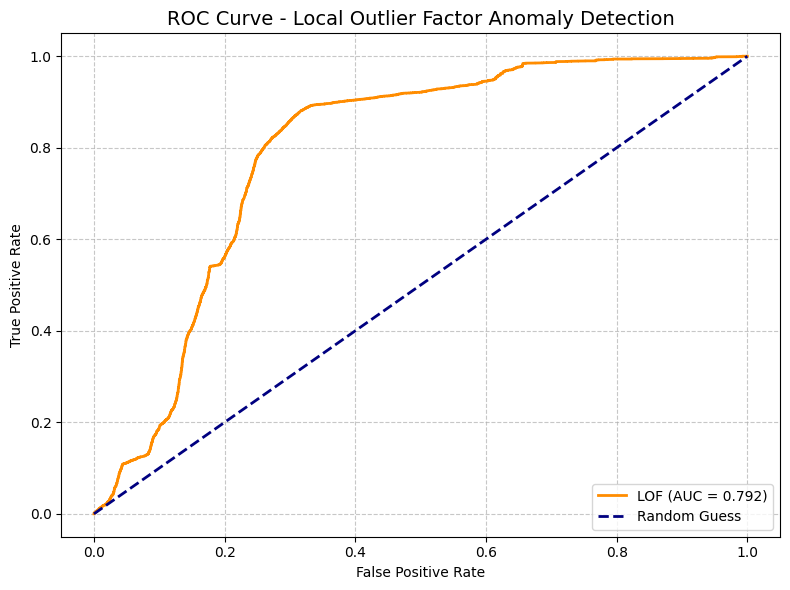

In [ ]:
# Get model probabilities
y_prob = lof.decision_function(X_test)

# Set 0 → 0 (anomaly), 1 → 1 (normal)
y_test_mapped = np.where(y_test == 0, 0, 1)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_mapped, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'LOF (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.title('ROC Curve - Local Outlier Factor Anomaly Detection', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

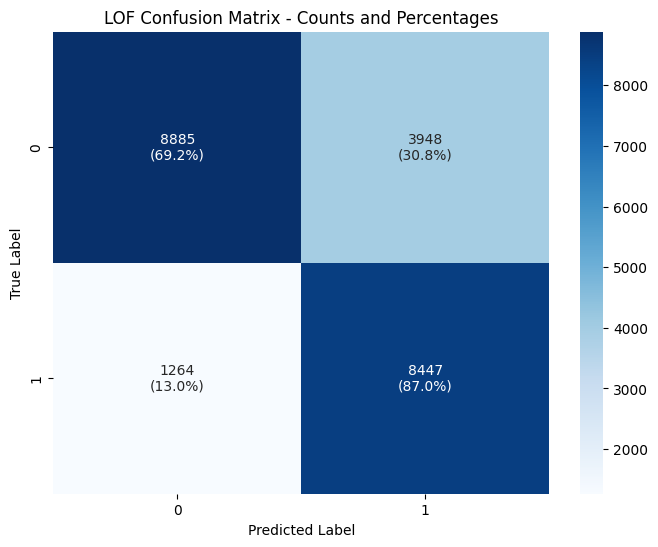

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test_mapped, y_pred)

# Convert to percentages
cm_percentage = (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100)

# Create labels with both counts and percentages
labels = np.array([["{0:d}\n({1:.1f}%)".format(count, percentage)
                   for count, percentage in zip(row_counts, row_percentages)]
                  for row_counts, row_percentages in zip(cm, cm_percentage)])

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title('LOF Confusion Matrix - Counts and Percentages')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()